In [2]:
import sys
sys.path.append("..")

import pandas as pd

from src.trading_strategy import compute_spread, compute_rolling_z, generate_signals
from src.pair_selection import find_correlated_pairs, find_cointegrated_pairs
from src.backtest import calculate_position_size

In [3]:
adj_close_df = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)

In [4]:
correlated_pairs = find_correlated_pairs(adj_close_df, 0.7)
cointegrated_pairs = find_cointegrated_pairs(adj_close_df, correlated_pairs, 0.05)
cointegrated_pairs.sort(key = lambda x: x[3])

In [5]:
first_pair = cointegrated_pairs[0]
print(first_pair)

('JBLU', 'LUV', np.float64(0.9504446769104575), np.float64(7.109656764761808e-05))


In [6]:
first_pair_alpha, first_pair_beta, first_pair_spread = compute_spread(adj_close_df, first_pair)
first_pair_rolling_z = compute_rolling_z(first_pair_spread, 60)
first_pair_signals = generate_signals(first_pair_rolling_z)
print(first_pair_signals)

Date
2017-01-03    0
2017-01-04    0
2017-01-05    0
2017-01-06    0
2017-01-09    0
             ..
2024-12-24    0
2024-12-26    0
2024-12-27    0
2024-12-30    0
2024-12-31    0
Length: 2012, dtype: int64


In [8]:
capital = 10000
x = first_pair[0]
y = first_pair[1]
pnl_list = []
for i in range(len(adj_close_df)):
    price_x = adj_close_df[x].iloc[i]
    price_y = adj_close_df[y].iloc[i]
    signal = first_pair_signals.iloc[i]
    if i == 0:
        pnl_list.append(0)
        if signal == -1 or signal == 1:
            shares_x, shares_y = calculate_position_size(capital, first_pair_beta, price_y, price_x)
    else:
        prev_signal = first_pair_signals.iloc[i-1]
        if prev_signal != 0:
            profit_x = (-shares_x * (price_x - adj_close_df[x].iloc[i-1])) * signal
            profit_y = (shares_y * (price_y - adj_close_df[y].iloc[i-1])) * signal
            pnl_list.append(profit_x + profit_y)
        else:
            pnl_list.append(0)
        if signal != 0 and signal != prev_signal: 
            shares_x, shares_y = calculate_position_size(capital, first_pair_beta, price_y, price_x)
pnl_series = pd.Series(pnl_list, index = adj_close_df.index)


<Axes: xlabel='Date'>

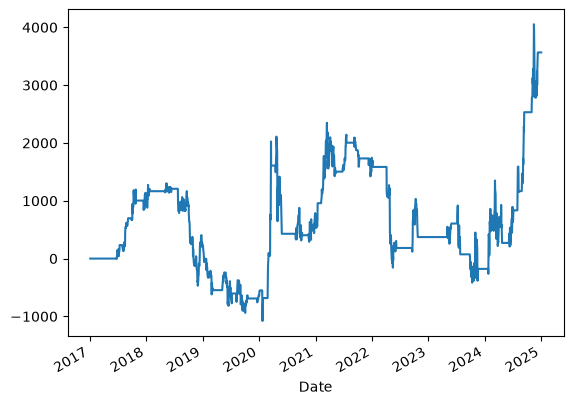

In [14]:
pd.Series(pnl_series).cumsum().plot()
          